# Project Name: Premium prediction for Health insurance

# Step-1: Data Loading + EDA + Data Cleaning

In [1]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("premiums_young_with_gr.xlsx")
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,Gold,11603,1
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,Gold,14498,2
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,Bronze,9111,5
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,Bronze,8564,4


# EDA + Data cleaning

In [3]:
df.shape

(20096, 14)

In [4]:
df.Age.unique()

array([18, 22, 21, 25, 20, 19, 23, 24])

In [5]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [6]:
df.columns = df.columns.str.lower()

In [7]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number of dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

In [8]:
df.columns = df.columns.str.replace(" ", "_")

In [9]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

# Handling of Null values

In [10]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [11]:
df.dropna(inplace = True)

In [12]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

# Handling Duplicate values

In [13]:
print(df.duplicated().sum())

0


In [14]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


## Resolve Negative value in number of dependent column

In [15]:
df[df.number_of_dependants < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
150,23,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Freelancer,10L - 25L,18,No Disease,Silver,9309,2
871,18,Male,Southwest,Unmarried,-3,Overweight,No Smoking,Freelancer,25L - 40L,28,No Disease,Silver,8095,0
906,19,Male,Northwest,Unmarried,-3,Underweight,No Smoking,Freelancer,25L - 40L,40,No Disease,Bronze,4641,1
2462,20,Male,Northeast,Unmarried,-3,Underweight,Regular,Freelancer,10L - 25L,20,Diabetes,Silver,9640,1
3059,20,Female,Southwest,Unmarried,-3,Underweight,No Smoking,Salaried,> 40L,77,No Disease,Silver,9299,2
3120,25,Male,Northwest,Unmarried,-1,Underweight,No Smoking,Salaried,10L - 25L,13,No Disease,Bronze,7234,3
3780,23,Female,Southeast,Unmarried,-3,Normal,Regular,Freelancer,25L - 40L,40,No Disease,Bronze,5003,0
5593,25,Male,Northwest,Unmarried,-1,Normal,No Smoking,Salaried,10L - 25L,20,No Disease,Bronze,6299,2
7585,22,Male,Northwest,Unmarried,-3,Normal,Occasional,Self-Employed,<10L,8,No Disease,Gold,13596,2
9765,18,Female,Southeast,Unmarried,-1,Underweight,No Smoking,Self-Employed,<10L,4,No Disease,Bronze,9366,5


In [16]:
df[df.number_of_dependants < 0]['number_of_dependants'].unique()

array([-3, -1])

In [17]:
# By mistage customer write +3 to -3 and +1 to -1
df.number_of_dependants = df.number_of_dependants.abs()

In [18]:
df.number_of_dependants.unique()

array([0, 2, 1, 3])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20090 entries, 0 to 20095
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20090 non-null  int64 
 1   gender                 20090 non-null  object
 2   region                 20090 non-null  object
 3   marital_status         20090 non-null  object
 4   number_of_dependants   20090 non-null  int64 
 5   bmi_category           20090 non-null  object
 6   smoking_status         20090 non-null  object
 7   employment_status      20090 non-null  object
 8   income_level           20090 non-null  object
 9   income_lakhs           20090 non-null  int64 
 10  medical_history        20090 non-null  object
 11  insurance_plan         20090 non-null  object
 12  annual_premium_amount  20090 non-null  int64 
 13  genetical_risk         20090 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.3+ MB


# Handling of Outliers

In [20]:
numeric_columns = df.select_dtypes(include = "int64").columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

## Box plot for Outliers

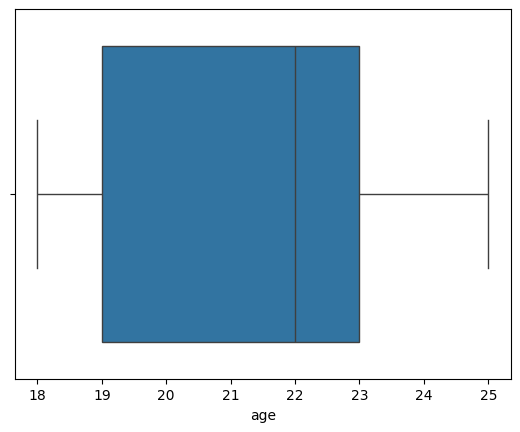

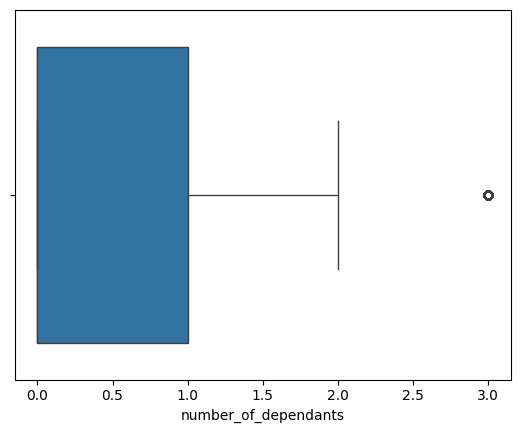

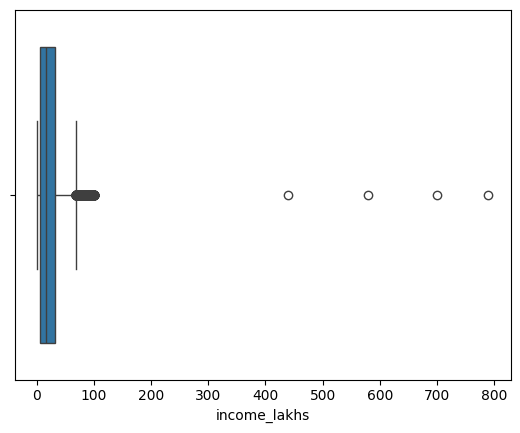

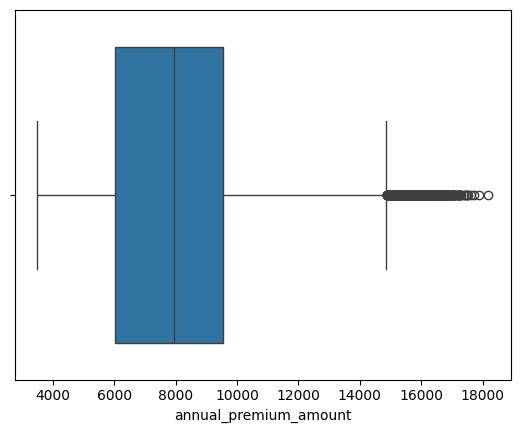

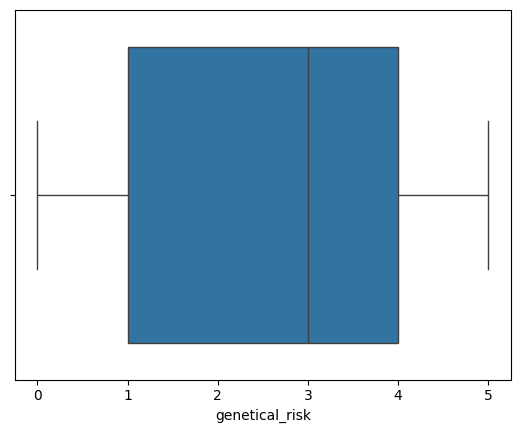

In [21]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

### Handling of outlier in age column

In [22]:
Q1 = np.percentile(df.age, 25)
Q3 = np.percentile(df.age, 75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
print(UB)

19.0
23.0
29.0


In [23]:
df[df.age > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [24]:
df[df.age > 100]['age'].unique()

array([], dtype=int64)

In [25]:
df[df.age > 100]['age'].value_counts()

Series([], Name: count, dtype: int64)

In [26]:
median_age = df.age.median()
print(median_age)

22.0


In [27]:
df.loc[df.age > 100, 'age'] = median_age

In [28]:
df[df.age > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Handling outliers in income_lakhs column

In [29]:
Q1 = np.percentile(df.income_lakhs, 25)
Q3 = np.percentile(df.income_lakhs, 75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
print(UB)

6.0
31.0
68.5


In [30]:
df[df.income_lakhs > 100].count()

age                      4
gender                   4
region                   4
marital_status           4
number_of_dependants     4
bmi_category             4
smoking_status           4
employment_status        4
income_level             4
income_lakhs             4
medical_history          4
insurance_plan           4
annual_premium_amount    4
genetical_risk           4
dtype: int64

In [31]:
df.shape

(20090, 14)

In [32]:
df[df.income_lakhs > 100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
1677,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,440,No Disease,Silver,10636,3
4311,20,Female,Southwest,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,580,Thyroid,Silver,12888,5
4661,21,Female,Southwest,Unmarried,0,Obesity,No Smoking,Freelancer,> 40L,700,No Disease,Bronze,7424,3
6251,21,Female,Southeast,Unmarried,0,Normal,Occasional,Salaried,> 40L,790,No Disease,Silver,7586,0


In [33]:
# deleted the Outliers
df = df[df.income_lakhs <= 100]

In [34]:
df[df.income_lakhs > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [35]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263,2.503883
std,2.294248,0.937238,21.732062,2749.912486,1.710184
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,100.000000,18186.000000,5.000000


## EDA & Data Cleaning on Categorical variables

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20086 entries, 0 to 20095
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20086 non-null  int64 
 1   gender                 20086 non-null  object
 2   region                 20086 non-null  object
 3   marital_status         20086 non-null  object
 4   number_of_dependants   20086 non-null  int64 
 5   bmi_category           20086 non-null  object
 6   smoking_status         20086 non-null  object
 7   employment_status      20086 non-null  object
 8   income_level           20086 non-null  object
 9   income_lakhs           20086 non-null  int64 
 10  medical_history        20086 non-null  object
 11  insurance_plan         20086 non-null  object
 12  annual_premium_amount  20086 non-null  int64 
 13  genetical_risk         20086 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.3+ MB


In [37]:
categorical_columns = df.select_dtypes(include = "object").columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [38]:
for col in categorical_columns:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : ['> 40L' '<10L' '10L - 25L' '25L - 40L']
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : ['Silver' 'Bronze' 'Gold']


In [39]:
df.smoking_status = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' : 'No Smoking'})

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_7948\1074089374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.smoking_status = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' : 'No Smoking'})


In [40]:
df.smoking_status.unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

# Step-2 : Feature Engineering

### convert the Categorical variable into Numerical variables

In [41]:
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

### Ordinal Encoding: Rank or Order 'income_level', 'insurance_plan'

In [42]:
from sklearn.preprocessing import OrdinalEncoder

In [43]:
encoder = OrdinalEncoder(categories = [['Bronze', 'Silver', 'Gold']])
df.insurance_plan = encoder.fit_transform(df[['insurance_plan']])

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_7948\1274939803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.insurance_plan = encoder.fit_transform(df[['insurance_plan']])


In [44]:
df.insurance_plan = df.insurance_plan.astype('int64')

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_7948\355962698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.insurance_plan = df.insurance_plan.astype('int64')


In [45]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,1,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,1,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,1,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,0,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,0,5712,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,> 40L,91,No Disease,2,11603,1
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,> 40L,57,Diabetes,2,14498,2
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,25L - 40L,35,No Disease,0,9111,5
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,25L - 40L,32,No Disease,0,8564,4


In [46]:
encoder = OrdinalEncoder(categories = [['<10L', '10L - 25L', '25L - 40L', '> 40L']])
df.income_level = encoder.fit_transform(df[['income_level']])

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_7948\2938848440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.income_level = encoder.fit_transform(df[['income_level']])


In [47]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,3.0,99,High blood pressure,1,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,0.0,3,No Disease,1,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,3.0,97,No Disease,1,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,1.0,15,No Disease,0,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,1.0,14,No Disease,0,5712,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,3.0,91,No Disease,2,11603,1
20092,23,Female,Northwest,Unmarried,0,Obesity,Occasional,Freelancer,3.0,57,Diabetes,2,14498,2
20093,24,Female,Northwest,Unmarried,0,Underweight,No Smoking,Self-Employed,2.0,35,No Disease,0,9111,5
20094,21,Male,Northwest,Unmarried,0,Normal,Regular,Freelancer,2.0,32,No Disease,0,8564,4


# Use Label encoding to convert categorical column to numerical number

In [48]:
for col in categorical_columns:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northeast' 'Northwest' 'Southeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Overweight' 'Underweight' 'Normal' 'Obesity']
smoking_status : ['Regular' 'No Smoking' 'Occasional']
employment_status : ['Self-Employed' 'Freelancer' 'Salaried']
income_level : [3. 0. 1. 2.]
medical_history : ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
insurance_plan : [1 0 2]


In [49]:
# Use label encoding when their is NO RANKING between the classes in the data

from sklearn.preprocessing import LabelEncoder

In [50]:
encoder = LabelEncoder()
df.region = encoder.fit_transform(df.region)

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_7948\166564218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.region = encoder.fit_transform(df.region)


In [51]:
encoder = LabelEncoder()
df.bmi_category = encoder.fit_transform(df.bmi_category)

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_7948\744827222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.bmi_category = encoder.fit_transform(df.bmi_category)


In [52]:
# One hot encoding: Convert categorical data to numerical
# When number of sub-categories are less
df = pd.get_dummies(df, columns = ['gender', 'marital_status', 'smoking_status', 'employment_status'], drop_first = True, dtype = int)

In [53]:
df

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,0,2,3.0,99,High blood pressure,1,13365,4,1,1,0,1,0,1
1,22,1,0,3,0.0,3,No Disease,1,11050,3,0,1,0,0,0,0
2,21,2,0,0,3.0,97,No Disease,1,11857,4,0,1,0,1,1,0
3,25,2,0,0,1.0,15,No Disease,0,5684,2,1,1,0,0,0,0
4,20,2,2,2,1.0,14,No Disease,0,5712,1,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,2,0,3,3.0,91,No Disease,2,11603,1,0,1,0,0,0,0
20092,23,1,0,1,3.0,57,Diabetes,2,14498,2,0,1,1,0,0,0
20093,24,1,0,3,2.0,35,No Disease,0,9111,5,0,1,0,0,0,1
20094,21,1,0,0,2.0,32,No Disease,0,8564,4,1,1,0,1,0,0


# Covert categorical column to numerical : Manually

In [54]:
df.medical_history.unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [55]:
risk_score = {
                'Diabetes' : 6,
                'High blood pressure' : 6,
                'Heart disease' : 8,
                'Thyroid' : 5,
                'No Disease' : 0,
                'Diabetes & High blood pressure' : 12,
                'High blood pressure & Heart disease' : 14,
                'Diabetes & Thyroid' : 11,
                'Diabetes & Heart disease' : 14
}
df.medical_history = df.medical_history.map(risk_score)

In [56]:
df

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,0,2,3.0,99,6,1,13365,4,1,1,0,1,0,1
1,22,1,0,3,0.0,3,0,1,11050,3,0,1,0,0,0,0
2,21,2,0,0,3.0,97,0,1,11857,4,0,1,0,1,1,0
3,25,2,0,0,1.0,15,0,0,5684,2,1,1,0,0,0,0
4,20,2,2,2,1.0,14,0,0,5712,1,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,18,2,0,3,3.0,91,0,2,11603,1,0,1,0,0,0,0
20092,23,1,0,1,3.0,57,6,2,14498,2,0,1,1,0,0,0
20093,24,1,0,3,2.0,35,0,0,9111,5,0,1,0,0,0,1
20094,21,1,0,0,2.0,32,0,0,8564,4,1,1,0,1,0,0


# Feature Scaling

In [57]:
from sklearn.preprocessing import MinMaxScaler

In [58]:
df.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk', 'gender_Male',
       'marital_status_Unmarried', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

In [59]:
cols_to_scale = ['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
      'gender_Male', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed']

In [60]:
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Remove the features which are related to each other

# Correaltion matrix + Heatmap

In [61]:
cm = df.corr()

<Axes: >

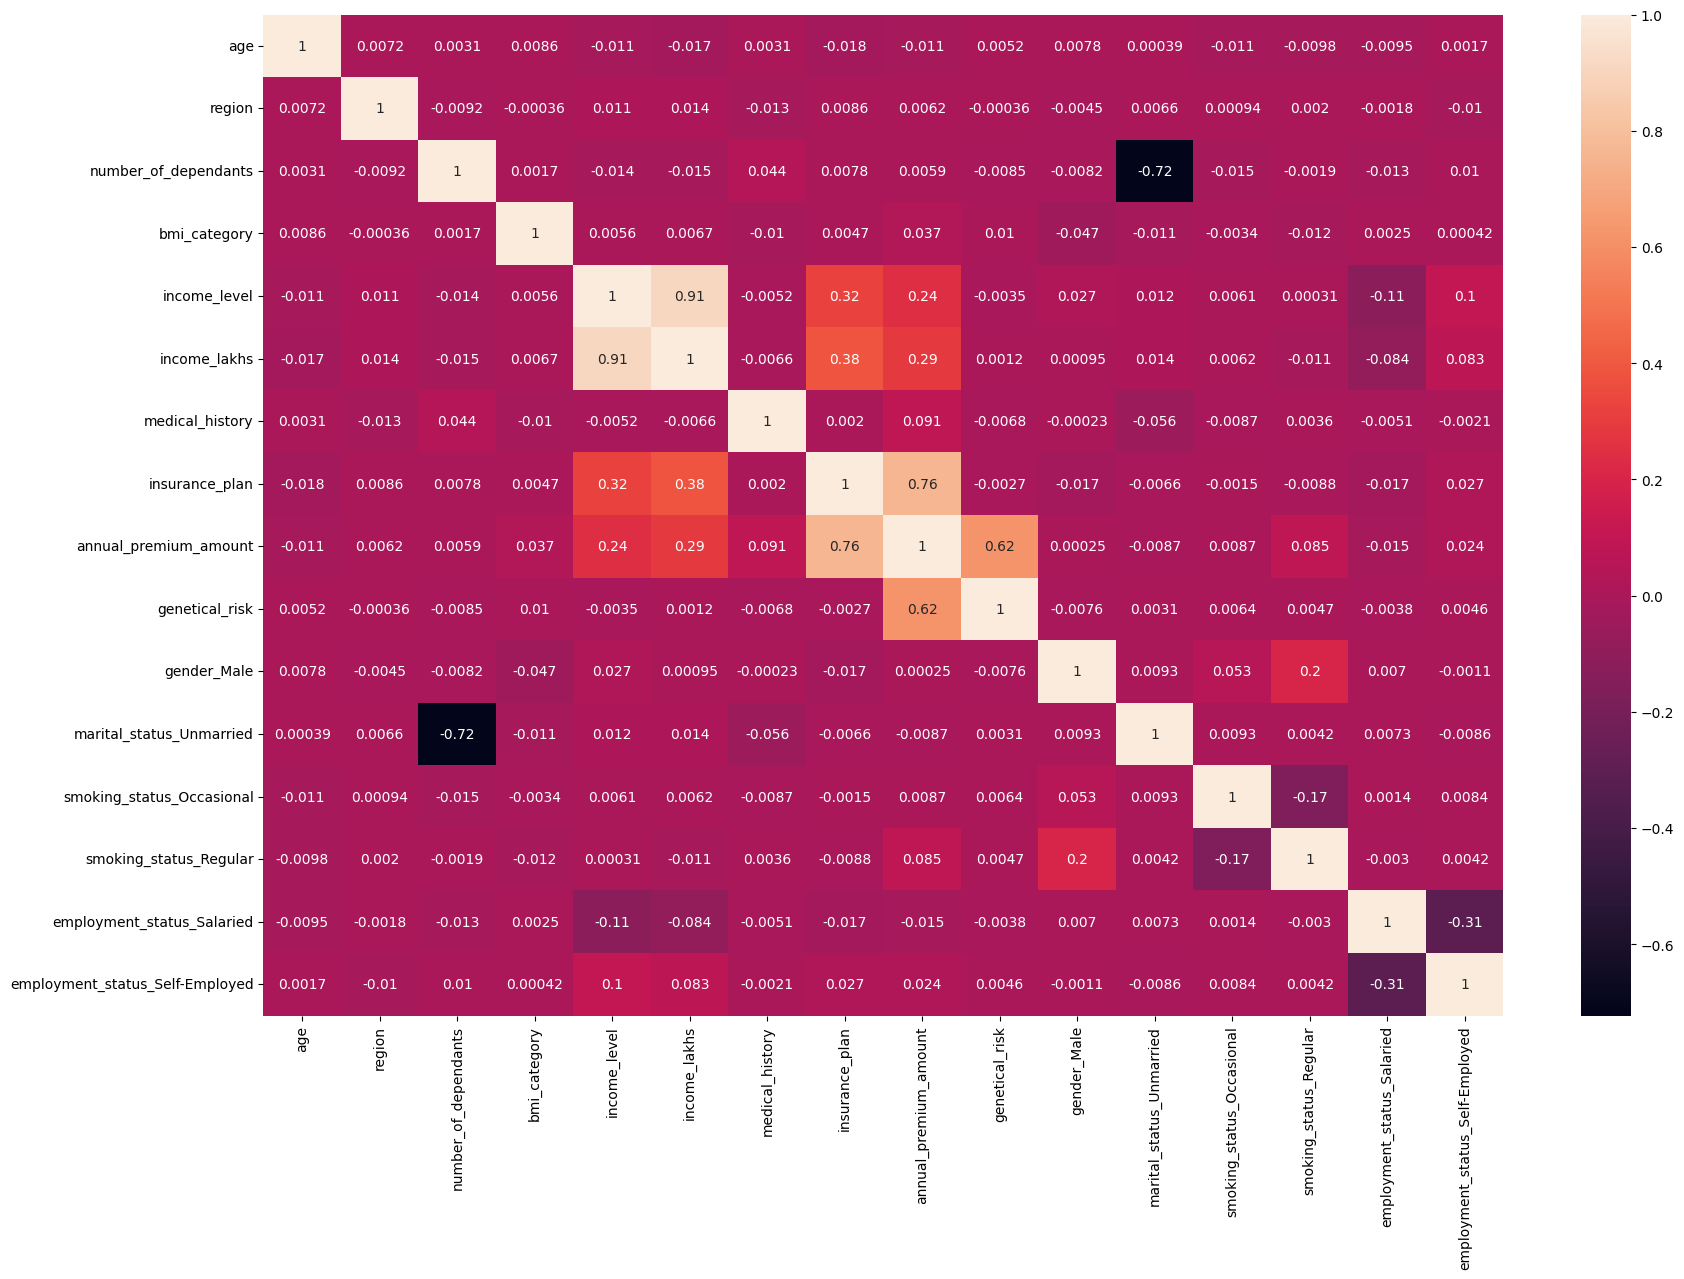

In [62]:
plt.figure(figsize = (20, 13))
sns.heatmap(cm, annot = True)

# Delete the highly correlated features : more than 80% related
 # number_of_dependents = marital_status_unmarried
# income_level = income_lakhs

# Don't delete the features which are related to target variable

In [63]:
df.drop(['marital_status_Unmarried', 'income_level'], axis = 1, inplace = True)

In [64]:
df.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'genetical_risk', 'gender_Male', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

# Step-4 : Model training & downloading/saving trained model

In [65]:
# Linear regresssion
# Xgboost

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
df

,age,region,number_of_dependants,bmi_category,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.000000,0.000000,0.666667,0.989899,0.428571,0.5,13365,4,1.0,0.0,1.0,0.0,1.0
1,0.571429,0.333333,0.000000,1.000000,0.020202,0.000000,0.5,11050,3,0.0,0.0,0.0,0.0,0.0
2,0.428571,0.666667,0.000000,0.000000,0.969697,0.000000,0.5,11857,4,0.0,0.0,1.0,1.0,0.0
3,1.000000,0.666667,0.000000,0.000000,0.141414,0.000000,0.0,5684,2,1.0,0.0,0.0,0.0,0.0
4,0.285714,0.666667,0.666667,0.666667,0.131313,0.000000,0.0,5712,1,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20091,0.000000,0.666667,0.000000,1.000000,0.909091,0.000000,1.0,11603,1,0.0,0.0,0.0,0.0,0.0
20092,0.714286,0.333333,0.000000,0.333333,0.565657,0.428571,1.0,14498,2,0.0,1.0,0.0,0.0,0.0
20093,0.857143,0.333333,0.000000,1.000000,0.343434,0.000000,0.0,9111,5,0.0,0.0,0.0,0.0,1.0
20094,0.428571,0.333333,0.000000,0.000000,0.313131,0.000000,0.0,8564,4,1.0,0.0,1.0,0.0,0.0


In [67]:
x = df.drop("annual_premium_amount", axis = 1)
y = df.annual_premium_amount
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state=42)

In [68]:
Linear_obj=LinearRegression()
Linear_obj.fit(x_train,y_train)

LinearRegression()

In [69]:
lr_score=Linear_obj.score(x_test,y_test)
print(lr_score)

0.9830185568816248


In [70]:
import xgboost as xgb

pip install --upgrade xgboost
# Your scikit-learn version is newer


# Your scikit-learn version is newer
👉 Your xgboost version is older

New versions of scikit-learn (>=1.6) expect models to implement __sklearn_tags__(),
but older xgboost versions don’t support it.

So when RandomizedSearchCV checks whether the model is a classifier/regressor, it crashes.

In [71]:
XGB_obj=xgb.XGBRegressor()

In [72]:
#hyper parameter tuning
from sklearn.model_selection import RandomizedSearchCV
param_gird={
    'n_estimators':[20,30,40,50],
    'learning_rate':[0.001,0.01,0.5],
    'max_depth':[3,4,5,6]
}
random_search=RandomizedSearchCV(XGB_obj,param_gird,cv=3)
random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.001, 0.01, 0.5],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [20, 30, 40, 50]})

In [73]:
random_search.best_score_

np.float64(0.9881738225618998)

In [74]:
# Target1: performnace must be greater than 97%
# Target 2:Difference between actual premium and predicated premium<10%

In [75]:
y_pred=random_search.predict(x_test)
y_pred

array([ 5470.6387,  9049.834 ,  5574.822 , ..., 12544.512 ,  4024.685 ,
        7985.8687], dtype=float32)

In [76]:
residuals=y_pred-y_test
residuals_pct=(residuals/y_test)*100
print(residuals_pct)

10489     0.341869
7989     -6.297018
3113     -7.563890
10605    -0.716905
4204     11.891196
           ...    
34        4.135467
11674    -7.651298
13904    -0.115362
2360     -7.072615
17721    -1.091545
Name: annual_premium_amount, Length: 4018, dtype: float64


In [77]:
result_df=pd.DataFrame({
    'Actaul':y_test,
    'Predicted':y_pred,
    'Diff':residuals,
    'Diff_pct':residuals_pct
})

In [78]:
result_df.head(10)

,Actaul,Predicted,Diff,Diff_pct
10489,5452,5470.638672,18.638672,0.341869
7989,9658,9049.833984,-608.166016,-6.297018
3113,6031,5574.821777,-456.178223,-7.563890
10605,12386,12297.204102,-88.795898,-0.716905
4204,4245,4749.781250,504.781250,11.891196
16419,15874,16032.136719,158.136719,0.996200
6534,12921,12387.913086,-533.086914,-4.125740
1712,5184,5568.792480,384.792480,7.422694
15712,7955,7861.799805,-93.200195,-1.171593
10360,9282,9088.155273,-193.844727,-2.088394


<Axes: xlabel='Diff_pct', ylabel='Count'>

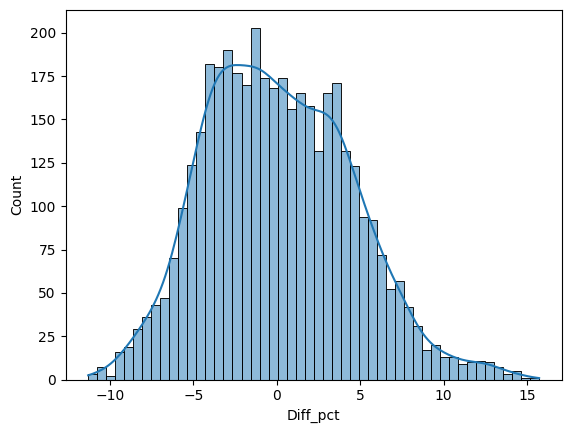

In [79]:
# plotting the chart 
# histplot to know the distribution OF difference percenatage b/w actual and predicated
import seaborn as sns
sns.histplot(result_df['Diff_pct'],bins=50,kde=True)

In [80]:
# extreme Data
extreme_result_df=result_df[np.abs(result_df.Diff_pct>10)]
extreme_result_df

,Actaul,Predicted,Diff,Diff_pct
4204,4245,4749.781250,504.781250,11.891196
3396,4568,5071.770508,503.770508,11.028251
13142,4215,4646.502930,431.502930,10.237317
7802,4096,4627.609375,531.609375,12.978745
9881,3952,4363.675293,411.675293,10.416885
...,...,...,...,...
8318,3527,3994.172607,467.172607,13.245608
10882,7313,8154.993652,841.993652,11.513656
14788,3549,4017.055908,468.055908,13.188389
10288,3623,4133.525391,510.525391,14.091234


In [81]:
extreme_result_df.shape

(78, 4)

In [82]:
# calculate percenatge
x_test.shape

(4018, 13)

In [83]:
(1523/9994)*100

15.239143486091656

### 5% values with more than 10% difference is allowed
### but we are getting 15% records having difference more than 10%

In [84]:
# finding complete record where extreme values exists
extreme_error_df=x_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,region,number_of_dependants,bmi_category,income_lakhs,medical_history,insurance_plan,genetical_risk,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
4204,0.000000,0.666667,0.000000,1.000000,0.222222,0.000000,0.0,0,0.0,0.0,1.0,0.0,0.0
3396,1.000000,0.333333,0.000000,0.000000,0.020202,0.000000,0.0,1,1.0,0.0,0.0,0.0,0.0
13142,0.571429,1.000000,0.666667,0.000000,0.070707,0.428571,0.0,0,0.0,1.0,0.0,1.0,0.0
7802,0.857143,0.666667,1.000000,1.000000,0.020202,0.357143,0.0,0,1.0,0.0,0.0,0.0,0.0
9881,0.714286,0.000000,0.000000,0.666667,0.040404,0.000000,0.0,0,1.0,0.0,0.0,1.0,0.0


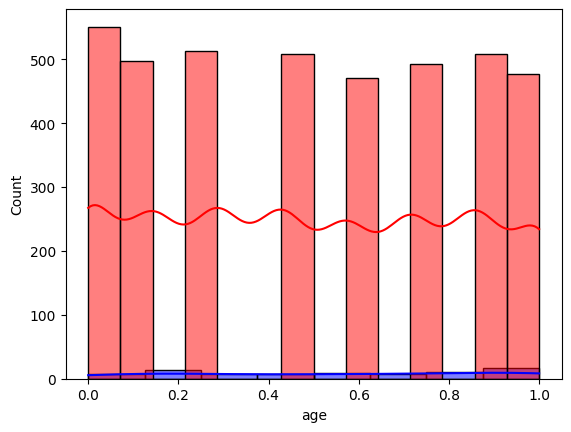

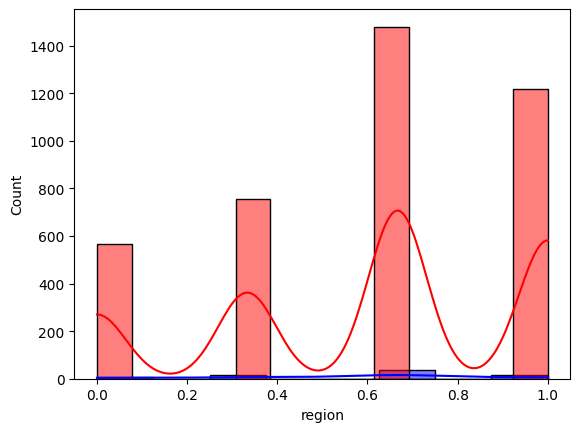

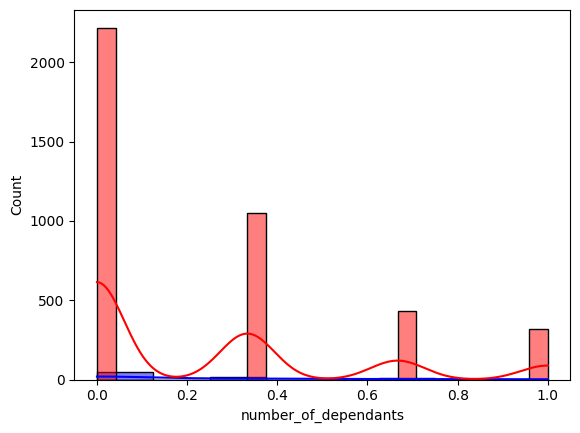

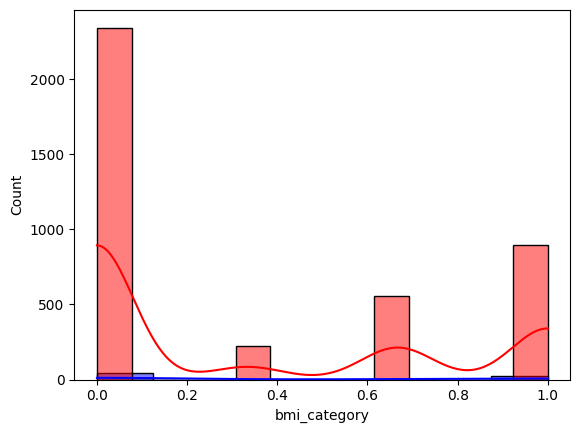

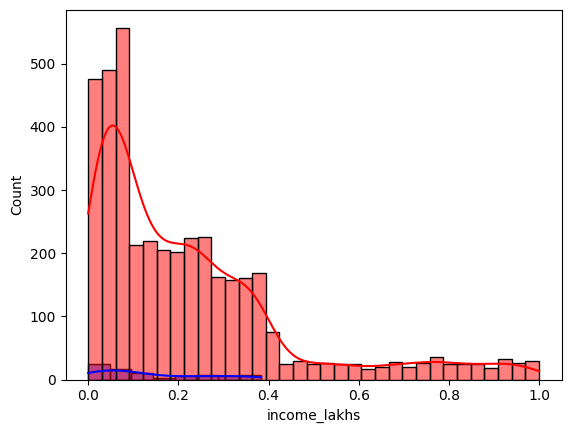

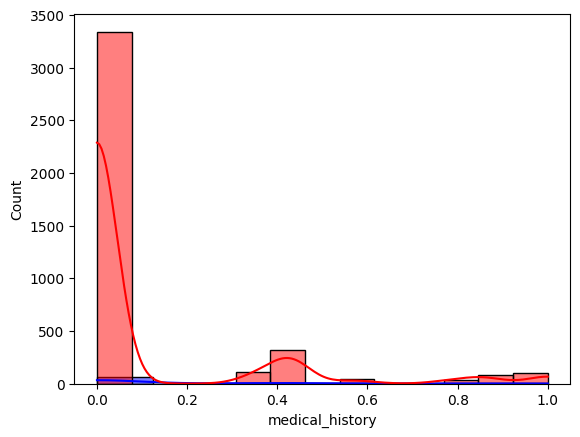

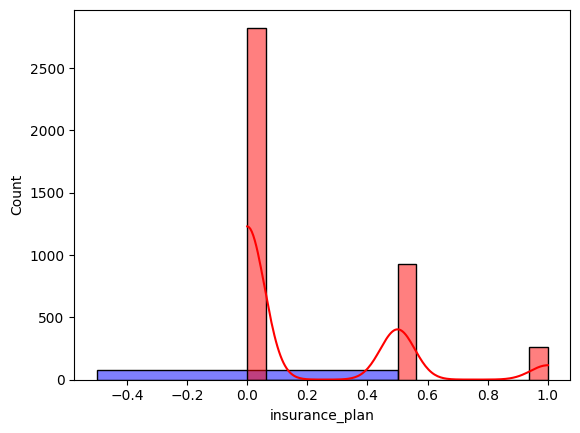

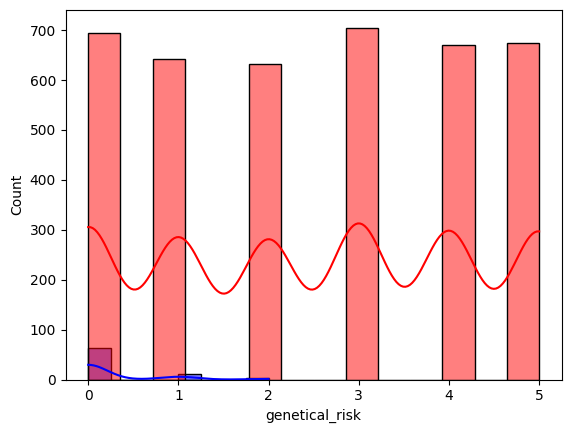

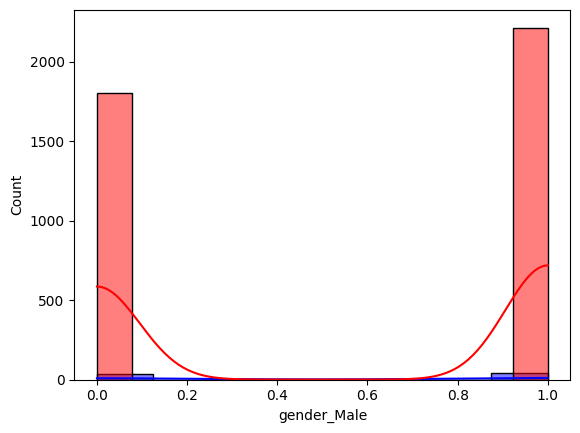

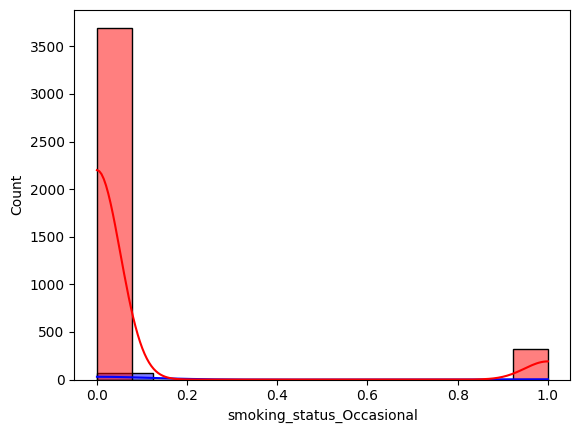

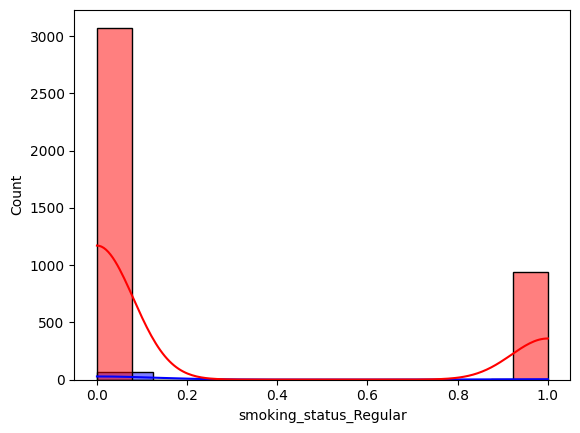

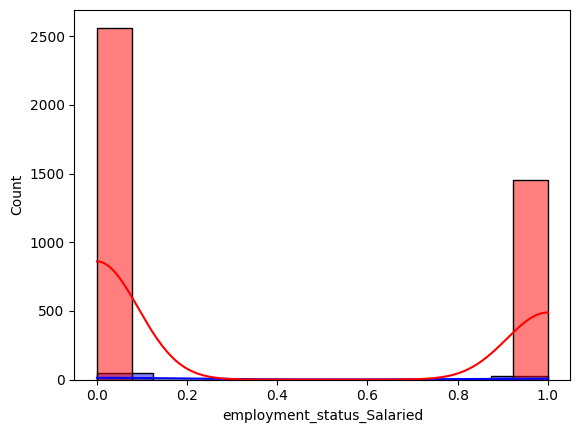

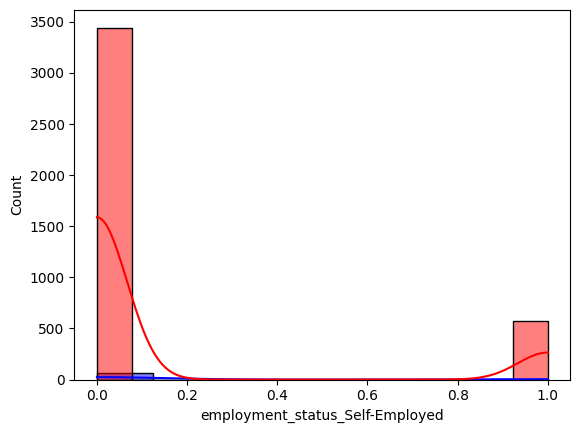

In [85]:
for features in x_test.columns:
    sns.histplot(extreme_error_df[features],color="Blue",kde=True)
    sns.histplot(x_test[features],color="red",kde=True)
    plt.show()

# reverse scaling
# segmentation

In [86]:
# I want to find the actual value of features (not the sacled value)
df_reversed=pd.DataFrame()
extreme_error_df['income_level']=-1
extreme_error_df['marital_status_Unmarried']=-1
df_reversed[cols_to_scale]=scaler.inverse_transform(extreme_error_df[cols_to_scale])
df_reversed

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18.0,2.0,0.0,3.0,-3.0,23.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0
1,25.0,1.0,0.0,0.0,-3.0,3.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
2,22.0,3.0,2.0,0.0,-3.0,8.0,6.0,0.0,0.0,-1.0,1.0,0.0,1.0,0.0
3,24.0,2.0,3.0,3.0,-3.0,3.0,5.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
4,23.0,0.0,0.0,2.0,-3.0,5.0,0.0,0.0,1.0,-1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,20.0,1.0,0.0,0.0,-3.0,5.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
74,18.0,2.0,0.0,0.0,-3.0,2.0,8.0,0.0,1.0,-1.0,0.0,1.0,0.0,0.0
75,25.0,2.0,3.0,0.0,-3.0,25.0,0.0,0.0,1.0,-1.0,0.0,0.0,1.0,0.0
76,25.0,2.0,0.0,3.0,-3.0,4.0,0.0,0.0,0.0,-1.0,0.0,0.0,1.0,0.0


In [87]:
# reverse_scaling for actual test data
x_test_copy=x_test.copy()
df_test_reversed=pd.DataFrame()
x_test_copy['income_level']=-1
x_test_copy['marital_status_Unmarried']=-1
df_test_reversed[cols_to_scale]=scaler.inverse_transform(x_test_copy[cols_to_scale])
df_test_reversed

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,21.0,0.0,3.0,0.0,-3.0,9.0,6.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
1,23.0,3.0,0.0,0.0,-3.0,4.0,14.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
2,19.0,3.0,0.0,0.0,-3.0,37.0,14.0,0.0,1.0,-1.0,0.0,1.0,1.0,0.0
3,21.0,2.0,0.0,2.0,-3.0,52.0,6.0,1.0,1.0,-1.0,0.0,0.0,0.0,0.0
4,18.0,2.0,0.0,3.0,-3.0,23.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4013,22.0,3.0,0.0,0.0,-3.0,9.0,0.0,1.0,1.0,-1.0,0.0,1.0,0.0,0.0
4014,21.0,1.0,2.0,0.0,-3.0,25.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
4015,23.0,0.0,1.0,0.0,-3.0,36.0,0.0,1.0,1.0,-1.0,0.0,0.0,0.0,1.0
4016,24.0,3.0,0.0,0.0,-3.0,23.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,1.0


In [88]:
x_test.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'medical_history', 'insurance_plan', 'genetical_risk', 'gender_Male',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

<Axes: xlabel='age', ylabel='Count'>

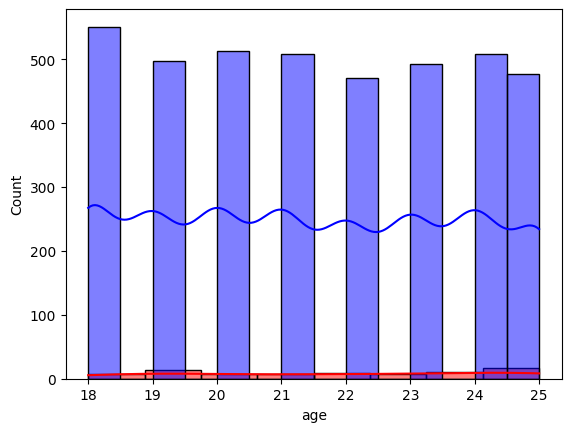

In [89]:
sns.histplot(df_reversed['age'],color='red',kde=True)
sns.histplot(df_test_reversed.age,color='blue',kde=True)

In [90]:
print((df_reversed.age<25).count())

78


In [91]:
# people below the age of 25 are unpredictable

# solution 1:Delete the entries below the age 25
# solution 2: segmentation 
# segmentation:
- segmentation is the process of dividing a large dataset or population into smaller groups that share similar characteristics to enable better analysis or decision-making.

In [92]:
df_young=df[df.age<=25]
df_rest=df[df.age>25]

# exporting the trained model and scaler object uisng joblib

In [93]:
best_model=random_search.best_estimator_
print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.5, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=20,
             n_jobs=None, num_parallel_tree=None, ...)


In [95]:
from joblib import dump


In [96]:
dump(best_model,"artifacts/model_young.joblib")
scaler_with_cols={
              'scaler':scaler,
              'cols_to_scale':cols_to_scale
}
dump(scaler_with_cols,"artifacts/scaler_young.joblib")

['artifacts/scaler_young.joblib']